## Multi-modality with CLIP

Neural network trained on a variety of (image, text) pairs. Can be instructed in natural language to predict the most relevant text snippet given an image.

![CLIP training](https://github.com/openai/CLIP/blob/main/CLIP.png?raw=true)

Can also use CLIP models to produce embeddings of images and texts into a shared vector space.

[Read more](https://openai.com/research/clip) | [GitHub repo](https://github.com/openai/CLIP)

### Set-up

#### Load models

In [1]:
from sentence_transformers import SentenceTransformer
from PIL import Image
import requests
from pathlib import Path

# The original clip-ViT-B-32 for encoding images
img_model = SentenceTransformer('clip-ViT-B-32')

# The second model is aligned - i.e. it maps to the same vector space as the original model
text_model = SentenceTransformer('sentence-transformers/clip-ViT-B-32-multilingual-v1')

# Read more about the models at:
# https://huggingface.co/sentence-transformers/clip-ViT-B-32
# https://huggingface.co/sentence-transformers/clip-ViT-B-32-multilingual-v1

c:\Users\akmal\anaconda3\envs\weaviate_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


#### data

In [2]:
import os
from dotenv import load_dotenv
import requests
from PIL import Image

load_dotenv()
TMDB_API_KEY = os.getenv("TMDB_API_KEY")
TMDB_BASE_URL = "https://api.themoviedb.org/3"
IMAGE_BASE_URL = "https://image.tmdb.org/t/p/w500"

# Ambil daftar film populer
response = requests.get(f"{TMDB_BASE_URL}/movie/popular?api_key={TMDB_API_KEY}")
movies = response.json()['results']

In [3]:
print(len(movies))

20


In [37]:
all_movies = []

for page in range(1, 101):  # page 1 sampai 3
    response = requests.get(
        f"{TMDB_BASE_URL}/movie/popular",
        params={"api_key": TMDB_API_KEY, "page": page}
    )
    page_movies = response.json()['results']
    all_movies.extend(page_movies)

print(f"Total film yang diambil: {len(all_movies)}")


Total film yang diambil: 2000


In [38]:
import json

with open("all_movies.json", "w", encoding="utf-8") as f:
    json.dump(all_movies, f, ensure_ascii=False, indent=2)


#### Helper functions

In [7]:
import json

with open('all_movies.json', 'r') as file:
    all_movies = json.load(file)

print(len(all_movies))


2000


In [8]:
# Helper function for loading an image or URL
def load_image(url_or_path):
    if url_or_path.startswith("http://") or url_or_path.startswith("https://"):
        return Image.open(requests.get(url_or_path, stream=True).raw)
    else:
        return Image.open(url_or_path)

In [19]:
from PIL import Image
from io import BytesIO
import requests

def load_image(url):
    response = requests.get(url)
    response.raise_for_status()  # agar error jika link rusak
    return Image.open(BytesIO(response.content))


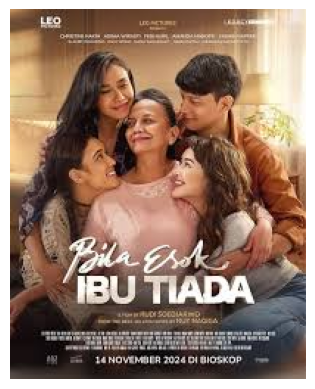

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

# Uji fungsi dengan path lokal
img = load_image("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQhjajyOS3zgZsSbmoIBVFBXVmNulW9FdQjjw&s")
plt.imshow(img)
plt.axis('off')
plt.show()


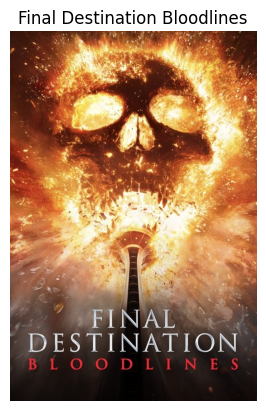

In [21]:
movie = all_movies[0]
IMAGE_BASE_URL = "https://image.tmdb.org/t/p/w500"
poster_url = IMAGE_BASE_URL + movie["poster_path"]

img = load_image(poster_url)

plt.imshow(img)
plt.axis('off')
plt.title(movie["title"])
plt.show()

In [11]:
import base64

# Helper function to convert a file to base64 representation
def to_base64(path):
    with open(path, 'rb') as file:
        return base64.b64encode(file.read()).decode('utf-8')

In [12]:
# weaviate tidak bisa menerima biner langsung jadi harus diubah ke str teks ASCII
# sama kayak JSON(misalnya lewat REST API)
# Tes fungsi to_base64
b64_str = to_base64("data/posters/5_poster.jpg")

# Tampilkan hasilnya (hanya sebagian agar tidak terlalu panjang)
print("Base64 Output (first 100 chars):")
print(b64_str[:100])

# Cek tipe dan panjang
print("Tipe:", type(b64_str))      # Harusnya <class 'str'>
print("Panjang:", len(b64_str))    # Panjang string Base64


Base64 Output (first 100 chars):
/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAYGBgYGBgcICAcKCgkKCg4NDAwNDhUPEA8QDxUgFBgUFBgUIB0jHBocIx0zKCQkKDM7
Tipe: <class 'str'>
Panjang: 64256


In [13]:
# Helper function for showing images in Jupyter (using Matplotlib)
import matplotlib.pyplot as plt

def show_images(response, src_img=None):
    # Load all 3 images into a list and show them in Jupyter with matplotlib
    images = [load_image(o.properties["file_path"]) for o in response.objects]
    if src_img:
        images = [src_img] + images
    _, axs = plt.subplots(1, len(images), figsize=(20, 10))
    for i, img in enumerate(images):
        axs[i].imshow(img)
        axs[i].axis('off')
    return None

#### Load data

In [5]:
# Use local paths for the dataset
# Data from TMDB; gathered through their API. (https://www.themoviedb.org/)
poster_img_dir = Path("data/posters")
poster_img_paths = [str(p) for p in poster_img_dir.glob("*.jpg")]

In [6]:
print(len(poster_img_paths))

90


In [14]:
load_dotenv()
API_KEY = os.getenv("API_KEY")
URL = os.getenv("URL")

### Connect to Weaviate

In [15]:
import weaviate
from weaviate.auth import AuthApiKey

client = weaviate.connect_to_wcs(
    cluster_url=URL,
    auth_credentials=AuthApiKey(API_KEY),
)

print("Connected:", client.is_ready())  # Harus True kalau berhasil


C:\Users\akmal\AppData\Local\Temp\ipykernel_14320\92729179.py:4: DeprecatedWarning: connect_to_wcs is deprecated as of 4.6.2. 
This method is deprecated and will be removed in a future release. Use :func:`connect_to_weaviate_cloud` instead.

  client = weaviate.connect_to_wcs(
c:\Users\akmal\anaconda3\envs\weaviate_env\Lib\site-packages\deprecation.py:260: DeprecationWarning: This method is deprecated and will be removed in a future release. Use `connect_to_weaviate_cloud` instead.
  return function(*args, **kwargs)


Connected: True


### Create a collection

In [17]:
import weaviate.classes as wvc

coll_name = "TMDBMovies"

client.collections.create(
    name=coll_name,
    vectorizer_config=wvc.config.Configure.Vectorizer.none(),
    generative_config=wvc.config.Configure.Generative.openai(),
    properties=[
        wvc.config.Property(name="file_path", data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name="img_source", data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name="image", data_type=wvc.config.DataType.BLOB),
        wvc.config.Property(name="title", data_type=wvc.config.DataType.TEXT),
        wvc.config.Property(name="overview", data_type=wvc.config.DataType.TEXT),
    ]
)


UnexpectedStatusCodeError: Collection may not have been created properly.! Unexpected status code: 422, with response body: {'error': [{'message': 'class name TMDBMovies already exists'}]}.

### Add data to the collection

In [24]:
import uuid
import base64

def load_image(url):
    response = requests.get(url)
    response.raise_for_status()  # naikkan exception jika gagal
    return Image.open(BytesIO(response.content)).convert("RGB")

def to_base64(url):
    response = requests.get(url)
    response.raise_for_status()
    return base64.b64encode(response.content).decode("utf-8")

def generate_uuid(value):
    namespace = uuid.NAMESPACE_URL  # atau bisa juga NAMESPACE_DNS
    return str(uuid.uuid5(namespace, value))
    
mm_coll = client.collections.get(coll_name)

import time
counter = 0
start_time = time.time()

with mm_coll.batch.dynamic() as batch:
    for movie in all_movies:  # ganti jumlah sesuai kebutuhan
        poster_path = movie.get("poster_path")
        if not poster_path:
            continue  # skip kalau tidak ada poster

        full_image_url = IMAGE_BASE_URL + poster_path
        title = movie.get("title", "No Title")
        overview = movie.get("overview", "No Overview")

        try:
            img = load_image(full_image_url)
            vector = img_model.encode([img])[0].tolist()
            img_b64 = to_base64(full_image_url)

            batch.add_object(
                properties={
                    "file_path": full_image_url,
                    "img_source": "TMDB",
                    "image": img_b64,
                    "title": title,
                    "overview": overview
                },
                vector=vector,
                uuid=generate_uuid(full_image_url)
            )

            counter += 1
            if counter % 25 == 0:
                print(f"Uploaded {counter} posters in {time.time() - start_time:.2f} seconds")
                start_time = time.time()

        except Exception as e:
            print(f"Error on '{title}': {e}")


Uploaded 25 posters in 13.96 seconds
Uploaded 50 posters in 13.21 seconds
Uploaded 75 posters in 20.99 seconds
Uploaded 100 posters in 31.24 seconds
Uploaded 125 posters in 12.65 seconds
Uploaded 150 posters in 13.71 seconds
Uploaded 175 posters in 13.28 seconds
Uploaded 200 posters in 13.15 seconds
Uploaded 225 posters in 13.52 seconds
Uploaded 250 posters in 12.64 seconds
Uploaded 275 posters in 12.71 seconds
Uploaded 300 posters in 14.54 seconds
Uploaded 325 posters in 13.17 seconds
Uploaded 350 posters in 12.64 seconds
Uploaded 375 posters in 13.98 seconds
Uploaded 400 posters in 12.58 seconds
Uploaded 425 posters in 12.93 seconds
Uploaded 450 posters in 13.91 seconds
Uploaded 475 posters in 14.63 seconds
Uploaded 500 posters in 14.11 seconds
Uploaded 525 posters in 16.53 seconds
Uploaded 550 posters in 15.86 seconds
Uploaded 575 posters in 14.50 seconds
Uploaded 600 posters in 13.38 seconds
Uploaded 625 posters in 12.13 seconds
Uploaded 650 posters in 14.95 seconds
Uploaded 675 po

## Queries!

### Get the collection object

In [25]:
mm_coll = client.collections.get(coll_name)

### Search objects by text

Showing movie posters closest to query: 'Final Destination'


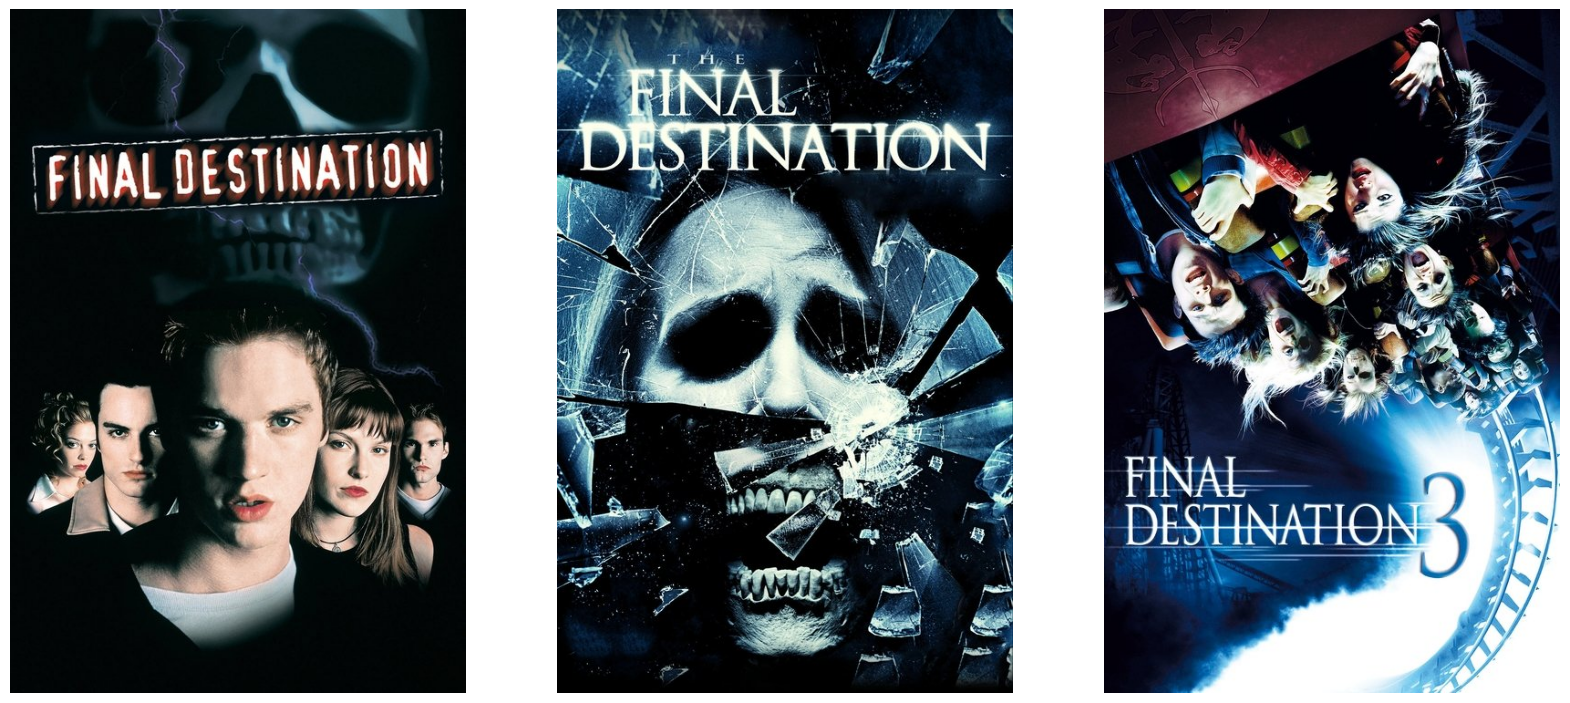

In [33]:
query = "Final Destination"
text_vec = text_model.encode([query])[0].tolist()

response = mm_coll.query.near_vector(
    near_vector=text_vec,
    return_properties=["image", "file_path"],
    filters=wvc.query.Filter.by_property("img_source").equal("TMDB"),
    limit=3
)

print(f"Showing movie posters closest to query: '{query}'")
show_images(response)


Showing movie posters closest to query: 'horror'


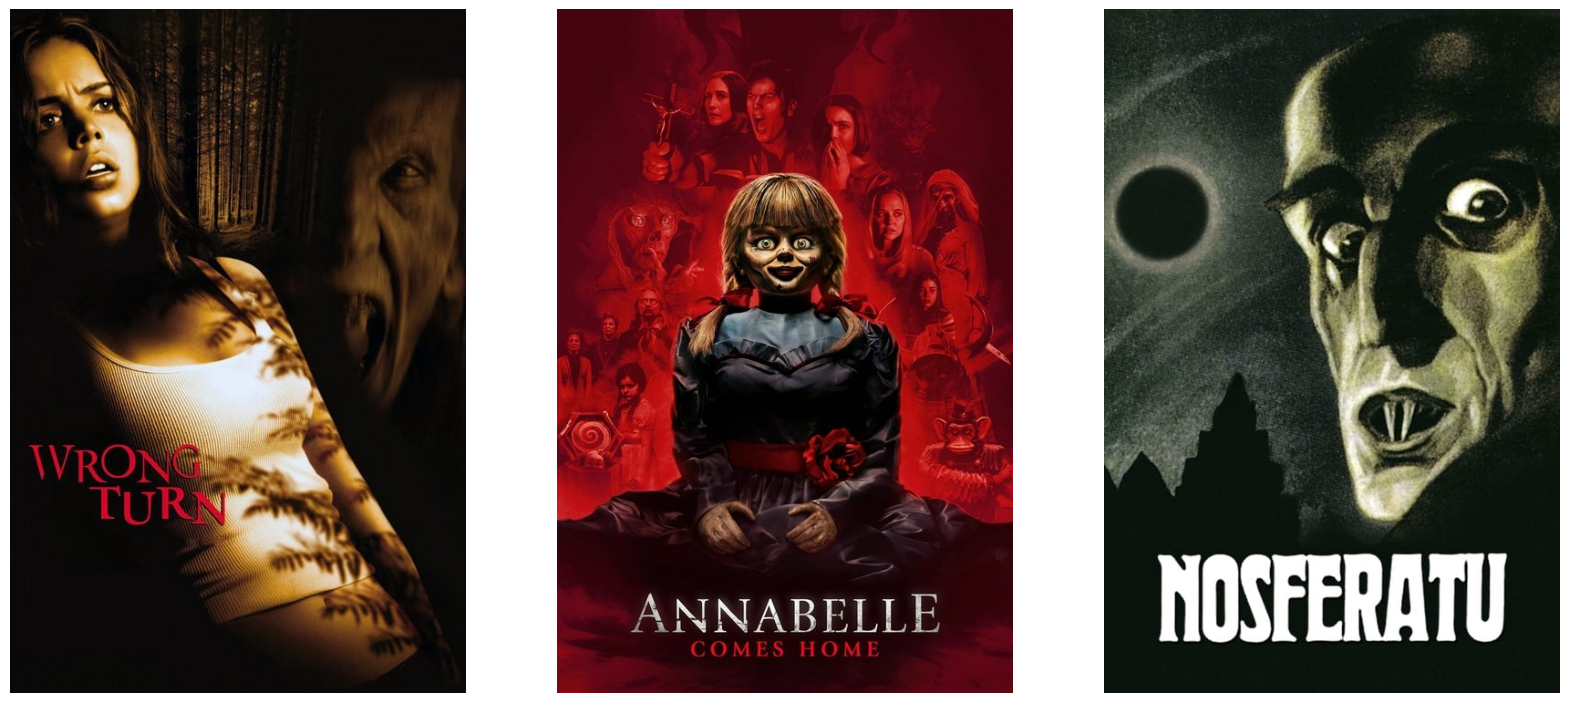

In [32]:

query = "horror"
text_vec = text_model.encode([query])[0].tolist()

response = mm_coll.query.near_vector(
    near_vector=text_vec,
    return_properties=["image", "file_path"],
    filters=wvc.query.Filter.by_property("img_source").equal("TMDB"),
    limit=3
)

print(f"Showing movie posters closest to query: '{query}'")
show_images(response)


### Search objects by image

In [35]:
movie1 = all_movies[0]  # ganti jumlah sesuai kebutuhan
poster_path1 = movie1.get("poster_path")
full_image_url1 = IMAGE_BASE_URL + poster_path1

Showing movie posters closest to the first (left-side) image


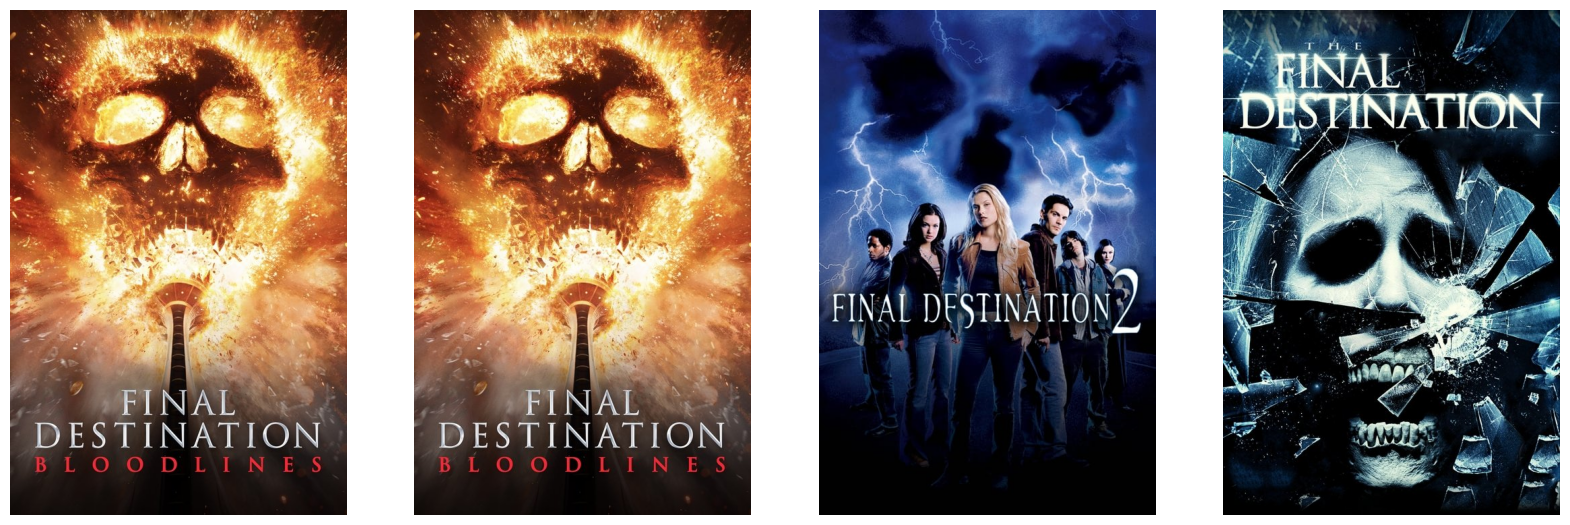

In [36]:
src_img = load_image(full_image_url1)
img_vec = img_model.encode([src_img])[0].tolist()

response = mm_coll.query.near_vector(
    near_vector=img_vec,
    return_properties=["image", "file_path"],
    filters=wvc.query.Filter.by_property("img_source").equal("TMDB"),
    limit=3
)

print(f"Showing movie posters closest to the first (left-side) image")
show_images(response, src_img)